In [1]:
import torch 
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
from PIL import Image
from torchvision import transforms
import requests 
from io import BytesIO
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt

2025-08-21 17:33:14.990609: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-21 17:33:15.006749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755772395.026289 2839580 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755772395.031938 2839580 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755772395.046554 2839580 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

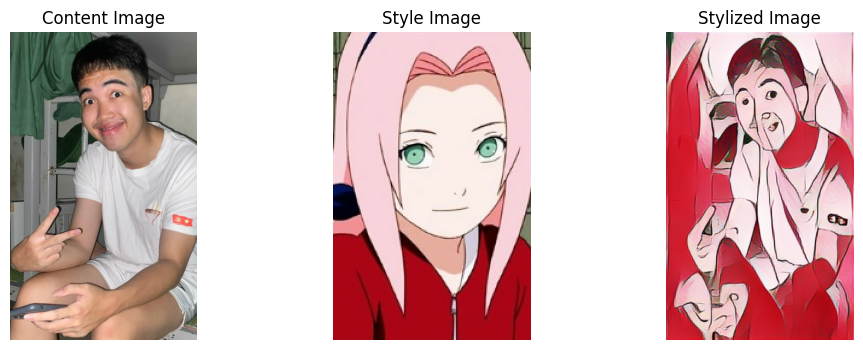

In [3]:
# Function to load and preprocess an image
def load_image(image_path, max_dim=512):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    
    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = tf.maximum(shape[0], shape[1])
    scale = max_dim / long_dim
    
    new_shape = tf.cast(shape * scale, tf.int32)
    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]  # Add batch dimension
    return img

# Load the pretrained model from TensorFlow Hub
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

# Load content and style images
content_image = load_image('/home/dang.cpm/__MY_SPACE__/Vintelligence/Github/Style_transfer/pretrained_model/input/chuong.jpg')
style_image = load_image('/home/dang.cpm/__MY_SPACE__/Vintelligence/Github/Style_transfer/pretrained_model/input/sakura.jpg', max_dim=256)  # Style image recommended at 256px

# Perform style transfer
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]

# Display the result
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Content Image')
plt.imshow(np.squeeze(content_image))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Style Image')
plt.imshow(np.squeeze(style_image))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Stylized Image')
plt.imshow(np.squeeze(stylized_image))
plt.axis('off')

plt.show()

# Optional: Save the stylized image
tf.keras.utils.save_img('output/stylized_image2.jpg', np.squeeze(stylized_image))